<a href="https://colab.research.google.com/github/chamcihn/MoblieSoftwareProject/blob/master/2_%EA%B8%B0%EB%B3%B8_%EB%AA%A8%EB%8D%B8%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**스마트폰 센서 데이터 기반 모션 분류**
# 단계2 : 기본 모델링


## 0.미션3

* 데이터 전처리
    * 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리 수행
* 다양한 딥러닝 구조의 모델로 분류 모델 생성
    * 최소 4개 이상 모델링 수행
    * 각 모델별 최소 5회 반복수행해서 얻은 성능의 평균으로 비교
    * 각 모델의 성능을 저장하는 별도 데이터 프레임을 만들고 비교
* 옵션 : 다음 사항은 선택사항입니다. 시간이 허용하는 범위 내에서 수행하세요.
    * 상위 N개 변수를 선정하여 모델링 및 성능 비교
        * 모델링에 항상 모든 변수가 필요한 것은 아닙니다.
        * 변수 중요도 상위 N개를 선정하여 모델링하고 타 모델과 성능을 비교하세요.
        * 상위 N개를 선택하는 방법은, 변수를 하나씩 늘려가며 모델링 및 성능 검증을 수행하여 적절한 지점을 찾는 것입니다.
* 성능 가이드
    * Accuracy : 0.90 ~ 0.99

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
path = '/content/drive/MyDrive/aivle/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩
     - pandas, numpy,matplotlib,seaborn, joblib, 모델링에 필요한 라이브러리를 로딩합니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

In [4]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [5]:
# 주어진 데이터 셋을 불러오세요.(3개)
train_df = pd.read_csv('/content/drive/MyDrive/aivle/data01_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/aivle/data01_test.csv')
feature_df = pd.read_csv('/content/drive/MyDrive/aivle/features.csv')


In [6]:
#불필요한 칼럼을 삭제하세요.

In [7]:
train_df.drop(columns=['subject'], inplace=True)
test_df.drop(columns=['subject'], inplace=True)

#### 2) 기본 정보 조회

In [8]:
#전체 데이터의 행,열 개수 확인
print("전체 행/열 개수:", train_df.shape)
print("전체 행/열 개수:", test_df.shape)
print("전체 행/열 개수:", feature_df.shape)

전체 행/열 개수: (5881, 562)
전체 행/열 개수: (1471, 562)
전체 행/열 개수: (561, 4)


In [9]:
#전체 데이터의 상위 5개 행 확인
print("전체 데이터 상위 5개", train_df.head())
print("전체 데이터 상위 5개", test_df.head())
print("전체 데이터 상위 5개", feature_df.head())

전체 데이터 상위 5개    tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288508          -0.009196          -0.103362         -0.988986   
1           0.265757          -0.016576          -0.098163         -0.989551   
2           0.278709          -0.014511          -0.108717         -0.997720   
3           0.289795          -0.035536          -0.150354         -0.231727   
4           0.394807           0.034098           0.091229          0.088489   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.962797         -0.967422         -0.989000         -0.962596   
1         -0.994636         -0.987435         -0.990189         -0.993870   
2         -0.981088         -0.994008         -0.997934         -0.982187   
3         -0.006412         -0.338117         -0.273557          0.014245   
4         -0.106636         -0.388502         -0.010469         -0.109680   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ... 

In [10]:
#전체 데이터의 수치형 변수 분포 확인
train_df.describe()
test_df.describe()
feature_df.describe()

,sensor,agg,axis,feature_name
count,561,561,436,561
unique,18,27,62,561
top,fBodyGyro,bandsEnergy(),X,"angle(Z,gravityMean)"
freq,79,126,76,1


In [11]:
#전체 데이터의 모든 변수 확인
train_df.info()
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sensor        561 non-null    object
 1   agg           561 non-null    object
 2   axis          436 non-null    object
 3   feature_name  561 non-null    object
dtypes: object(4)
memory usage: 17.7+ KB


## **2. 데이터 전처리**

* 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리를 수행한다.


### (1) 데이터 분할1 : x, y

* 세부 요구사항
    - x, y로 분할합니다.

In [12]:
x = train_df.drop(columns=['Activity'])
y = train_df['Activity']

In [13]:
# 데이터 분할을 합니다.
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state = 20)

### (2) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [14]:
#스케일링 방식을 선택해서 스케일링을 진행합니다.
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

### (3) Y 전처리
* integer encoding : LabelEncoder
* (필요시) one-hot encoding

In [15]:
# 정수 인코딩 변환(LabelEncoder)
le = LabelEncoder()
y = le.fit_transform(y)

In [16]:
# 기존 레이블 저장

### (4) 데이터분할2 : train, validation

* 세부 요구사항
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

In [17]:
#데이터 분할 진행(train:val = 8:2 혹은 7:3 권장)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

## **3. 기본 모델링**



* 세부 요구사항
    - 모델1 : Base line 모델
        * Hidden Layer 없이 모델 생성
    - 모델2 : 복잡한 모델 생성
        * 최소 5개 이상의 은닉층을 추가한 모델
    - 모델3 ~ n : 튜닝 모델
        * 학습률, epoch 등 조정
        * 모델2에 과적합을 방지하기 위한 규제 기법 추가
        * Accuracy 최대화 시키는 모델 생성하기
    - (옵션) 각 모델은 최소 5번 반복수행해서 얻은 성능의 평균값을 기록

### (1) 모델1 : Hidden Layer 없이 모델 생성

In [18]:
# 모델 설계
model1 = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(len(np.unique(y)), activation='softmax')
])

In [19]:
# 컴파일 및 학습
loss_fn = 'sparse_categorical_crossentropy'
optimizer = Adam(learning_rate= 0.2)
model1.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

epochs = 5
tr_loss_list = []
val_loss_list = []


for t in range(epochs):
    # 학습 1 epoch
    hist = model1.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=1, verbose=0)
    tr_loss = hist.history['loss'][0]
    val_loss = hist.history['val_loss'][0]

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)


    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")


Epoch 1, train loss : 6.4869, val loss : 0.6271
Epoch 2, train loss : 0.6695, val loss : 0.3643
Epoch 3, train loss : 0.6023, val loss : 0.9442
Epoch 4, train loss : 0.4457, val loss : 0.1863
Epoch 5, train loss : 0.7049, val loss : 0.3271


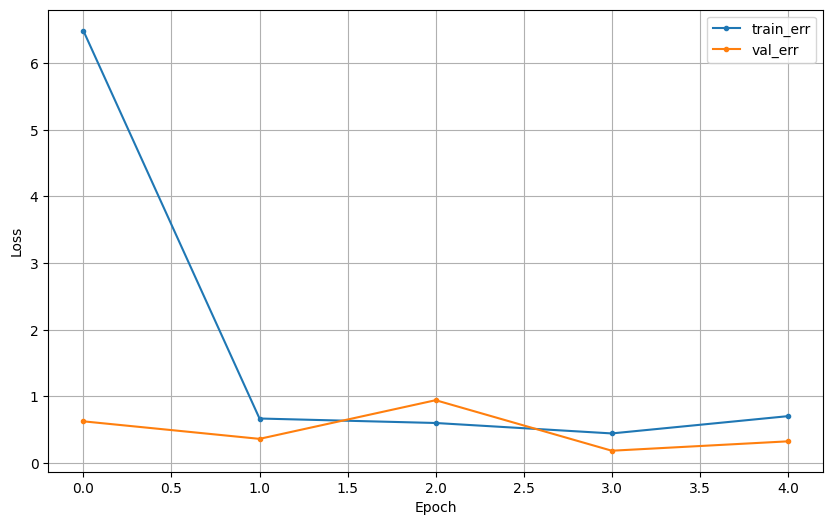

In [20]:
# 학습곡선
dl_history_plot({
    'loss': tr_loss_list,
    'val_loss': val_loss_list
})



In [21]:
# 예측 및 평가
from sklearn.metrics import accuracy_score

pred = model1.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
최종 정확도: 0.9643


In [22]:
#(옵션) 모델1번을 최소 5번 반복수행해서 얻은 성능의 평균값을 기록해보자!
repeat = 5
acc_list = []

for i in range(repeat):
    clear_session()  # 매 반복마다 세션 초기화

    # 모델 생성
    model = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(len(np.unique(y)), activation='softmax')
    ])

    # 컴파일
    optimizer = Adam(learning_rate=0.01)  # 학습률은 안정적인 값으로 설정 추천
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # 학습
    model.fit(x_train, y_train,
              validation_data=(x_val, y_val),
              batch_size=64,
              epochs=5,
              verbose=0)

    # 평가
    pred = model.predict(x_val)
    pred_label = np.argmax(pred, axis=1)
    acc = accuracy_score(y_val, pred_label)
    acc_list.append(acc)

    print(f"[반복 {i+1}] 정확도: {acc:.4f}")

# 평균 정확도 출력
print(f"\n 모델1 평균 정확도 (5회 반복): {np.mean(acc_list):.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[반복 1] 정확도: 0.9592
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[반복 2] 정확도: 0.9252
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[반복 3] 정확도: 0.9660
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[반복 4] 정확도: 0.9584
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[반복 5] 정확도: 0.9635

 모델1 평균 정확도 (5회 반복): 0.9545


### (2) 모델2 : 최소 5개 이상의 은닉층을 추가한 모델

In [23]:
# 모델 설계
model2 = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])

In [24]:
# 컴파일 및 학습
# 컴파일 및 학습
loss_fn = 'sparse_categorical_crossentropy'
optimizer = Adam(learning_rate= 0.001)
model2.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

epochs = 5
tr_loss_list = []
val_loss_list = []


for t in range(epochs):
    # 학습 1 epoch
    hist2 = model2.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=1, verbose=0)
    tr_loss = hist2.history['loss'][0]
    val_loss = hist2.history['val_loss'][0]

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)


    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")


Epoch 1, train loss : 1.1458, val loss : 0.4946
Epoch 2, train loss : 0.2965, val loss : 0.2045
Epoch 3, train loss : 0.1682, val loss : 0.1882
Epoch 4, train loss : 0.1403, val loss : 0.1212
Epoch 5, train loss : 0.1302, val loss : 0.1030


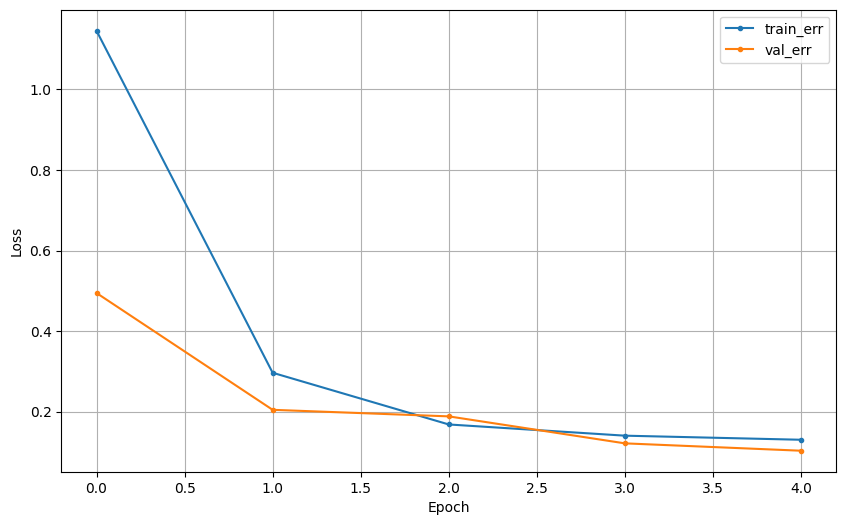

In [25]:
# 학습곡선
dl_history_plot({
    'loss': tr_loss_list,
    'val_loss': val_loss_list
})



In [26]:
# 예측 및 평가

pred = model2.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
최종 정확도: 0.9652


### (3) 모델3 : 학습률, epoch 등 조정

In [27]:
# 모델 설계
model3 = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(len(np.unique(y_train)), activation='softmax')
])

In [28]:
# 컴파일 및 학습
loss_fn = 'sparse_categorical_crossentropy'
optimizer = Adam(learning_rate= 0.002)
model3.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

epochs = 20
tr_loss_list = []
val_loss_list = []


for t in range(epochs):
    # 학습 1 epoch
    hist3 = model3.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=1, verbose=0)
    tr_loss = hist3.history['loss'][0]
    val_loss = hist3.history['val_loss'][0]

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)


    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")


Epoch 1, train loss : 1.4650, val loss : 0.9554
Epoch 2, train loss : 0.8635, val loss : 0.6011
Epoch 3, train loss : 0.6616, val loss : 0.5083
Epoch 4, train loss : 0.5763, val loss : 0.4654
Epoch 5, train loss : 0.5062, val loss : 0.3284
Epoch 6, train loss : 0.4146, val loss : 0.2937
Epoch 7, train loss : 0.4166, val loss : 0.3287
Epoch 8, train loss : 0.3526, val loss : 0.2836
Epoch 9, train loss : 0.3497, val loss : 0.2406
Epoch 10, train loss : 0.3242, val loss : 0.2241
Epoch 11, train loss : 0.3025, val loss : 0.2150
Epoch 12, train loss : 0.2786, val loss : 0.1896
Epoch 13, train loss : 0.2684, val loss : 0.1723
Epoch 14, train loss : 0.2737, val loss : 0.1480
Epoch 15, train loss : 0.2569, val loss : 0.1734
Epoch 16, train loss : 0.2720, val loss : 0.1954
Epoch 17, train loss : 0.2679, val loss : 0.1632
Epoch 18, train loss : 0.2545, val loss : 0.1444
Epoch 19, train loss : 0.2161, val loss : 0.1597
Epoch 20, train loss : 0.2437, val loss : 0.1643


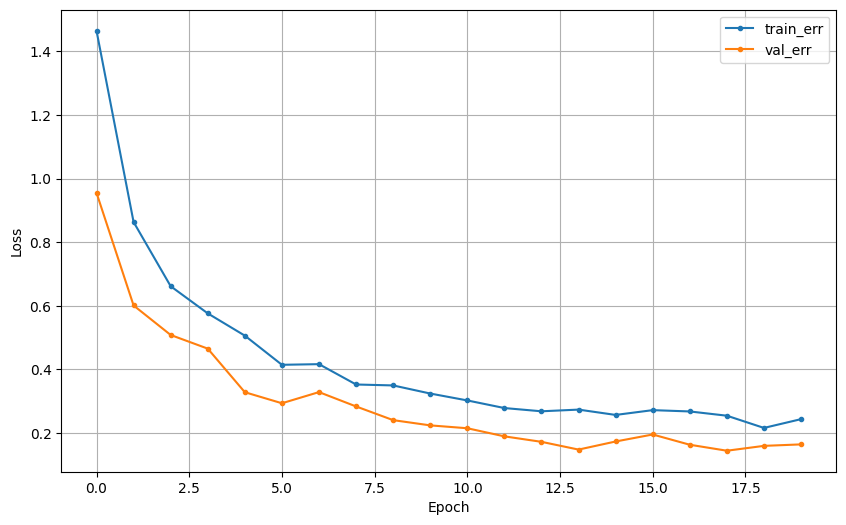

In [29]:
# 학습곡선
dl_history_plot({
    'loss': tr_loss_list,
    'val_loss': val_loss_list
})

In [30]:
# 예측 및 평가

pred = model3.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
최종 정확도: 0.9414


### (4) 모델4 :  학습률, epoch 등 조정

In [31]:
# 모델 설계
model4 = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(len(np.unique(y_train)), activation='softmax')
])

In [32]:
# 컴파일 및 학습
loss_fn = 'sparse_categorical_crossentropy'
optimizer = Adam(learning_rate= 0.001)
model4.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

epochs = 30
tr_loss_list = []
val_loss_list = []


for t in range(epochs):
    # 학습 1 epoch
    hist4 = model4.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=1, verbose=0)
    tr_loss = hist4.history['loss'][0]
    val_loss = hist4.history['val_loss'][0]

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)


    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")


Epoch 1, train loss : 1.5876, val loss : 1.0961
Epoch 2, train loss : 1.0250, val loss : 0.6468
Epoch 3, train loss : 0.7075, val loss : 0.5055
Epoch 4, train loss : 0.5992, val loss : 0.4650
Epoch 5, train loss : 0.5350, val loss : 0.4228
Epoch 6, train loss : 0.4737, val loss : 0.3766
Epoch 7, train loss : 0.4141, val loss : 0.2395
Epoch 8, train loss : 0.3325, val loss : 0.1931
Epoch 9, train loss : 0.2885, val loss : 0.1624
Epoch 10, train loss : 0.2528, val loss : 0.1490
Epoch 11, train loss : 0.2349, val loss : 0.1402
Epoch 12, train loss : 0.2202, val loss : 0.1179
Epoch 13, train loss : 0.2144, val loss : 0.0999
Epoch 14, train loss : 0.1847, val loss : 0.1283
Epoch 15, train loss : 0.1681, val loss : 0.0953
Epoch 16, train loss : 0.1484, val loss : 0.0973
Epoch 17, train loss : 0.1608, val loss : 0.0926
Epoch 18, train loss : 0.1385, val loss : 0.0901
Epoch 19, train loss : 0.1388, val loss : 0.0705
Epoch 20, train loss : 0.1311, val loss : 0.0674
Epoch 21, train loss : 0.1399

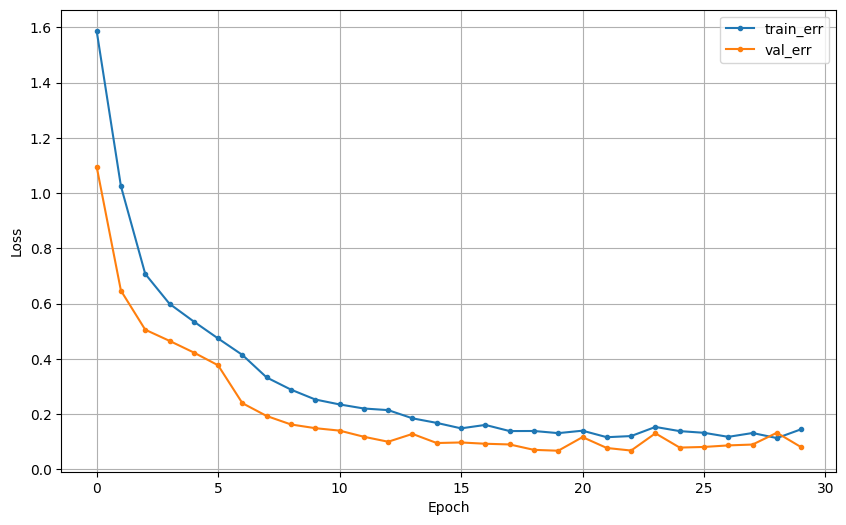

In [33]:
# 학습곡선
dl_history_plot({
    'loss': tr_loss_list,
    'val_loss': val_loss_list
})

In [34]:
# 예측 및 평가

pred = model4.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
최종 정확도: 0.9686


## 4.성능비교

* 세부 요구사항
    - test 데이터에 대한 전처리
    - 각 모델에 대해서 test 데이터로 성능 측정

In [35]:
#전체 데이터 불러오기(test)
# 1. test 데이터 불러오기
test_df = pd.read_csv('/content/drive/MyDrive/aivle/data01_test.csv')

# 2. subject 컬럼 삭제
test_df = test_df.drop(columns=['subject'])

# 3. x, y 분리
x_test = test_df.drop(columns=['Activity'])
y_test = test_df['Activity']

# 4. 스케일링 적용 (train에서 학습한 scaler 사용)
x_test = scaler.transform(x_test)

# 5. 정수 인코딩 적용 (train에서 학습한 label encoder 사용)
y_test = le.transform(y_test)


In [37]:
### 모델1
acc_list_1 = []
for i in range(5):
    clear_session()
    model1 = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(len(np.unique(y_train)), activation='softmax')
    ])
    model1.compile(optimizer=Adam(learning_rate=0.01),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model1.fit(x_train, y_train, epochs=5, batch_size=64, verbose=0)

    y_pred = model1.predict(x_test)
    acc = accuracy_score(y_test, np.argmax(y_pred, axis=1))
    acc_list_1.append(acc)
    print(f"[모델1 반복 {i+1}] 정확도: {acc:.4f}")
results['모델1'] = np.mean(acc_list_1)

### 모델2
acc_list_2 = []
for i in range(5):
    clear_session()
    model2 = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(len(np.unique(y_train)), activation='softmax')
    ])
    model2.compile(optimizer=Adam(learning_rate=0.005),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model2.fit(x_train, y_train, epochs=30, batch_size=64, verbose=0)

    y_pred = model2.predict(x_test)
    acc = accuracy_score(y_test, np.argmax(y_pred, axis=1))
    acc_list_2.append(acc)
    print(f"[모델2 반복 {i+1}] 정확도: {acc:.4f}")
results['모델2'] = np.mean(acc_list_2)

### 모델3
acc_list_3 = []
for i in range(5):
    clear_session()
    model3 = Sequential([
        Input(shape=(x_train.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(len(np.unique(y_train)), activation='softmax')
    ])
    model3.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model3.fit(x_train, y_train, epochs=30, batch_size=64, verbose=0)

    y_pred = model3.predict(x_test)
    acc = accuracy_score(y_test, np.argmax(y_pred, axis=1))
    acc_list_3.append(acc)
    print(f"[모델3 반복 {i+1}] 정확도: {acc:.4f}")
results['모델3'] = np.mean(acc_list_3)



46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[모델1 반복 1] 정확도: 0.4494


NameError: name 'results' is not defined

In [ ]:
print("\n📊 모델별 평균 test 정확도:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

#### 고생하셨습니다! 이제 단계적 모델링을 해봅시다.